# **Activity 2: Exploring the Gemini API (Part 1/2) - Group 3**

**Group members:**
- Abdullah Ali Saleem
- Danil Seksenov
- Nikita Soo
- Fatih Özdil

##**Part 1: Setup and Initialization**

**1.1 Create an API key**

---

Done :)

**1.2 Add your key to Colab Secrets**

---

Done :)

**1.3 Install SDK and Initialize Client**

---

In [ ]:
%pip install -q google-genai gradio

In [ ]:
# Core Gemini and Colab libraries
import google.generativeai as genai
from google.generativeai import types
from google.colab import userdata

# Gradio for UI
import gradio as gr

# Utilities for display, file handling, JSON, etc.
from IPython.display import Markdown, Image as IPImage
import json
from pydantic import BaseModel, Field # For structured JSON later
from typing import Optional, List    # For type hinting later
import requests                      # For downloading files
import pathlib                       # For handling file paths
from PIL import Image as PILImage    # For image manipulation
import io                            # For handling byte streams
import time                          # For delays (e.g., waiting for file processing)
import base64                        # For potential image decoding

print("Libraries imported successfully.")

Libraries imported successfully.


**1.4 Initialize API Client and Select Model**

---

In [ ]:
# Retrieve the API key from Colab Secrets
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

# Configure the API key for the generative AI library
# If the key is invalid or missing, this line will likely cause an an error.
genai.configure(api_key=GOOGLE_API_KEY)

print("Gemini API configured.")

# Choose a model ID to use for subsequent requests
MODEL_ID = "gemini-2.5-flash" # @param ["gemini-2.5-flash-lite", "gemini-3.1-flash-lite-preview"] {"allow-input":true, isTemplate: true}
print(f"Using Model ID: {MODEL_ID}")

Gemini API configured.
Using Model ID: gemini-2.5-flash


##**Part 2: Basic Text Generation**

**Task 2.1: Simple Text Prompt**

---

In [ ]:
prompt = "What is the capital of italy?"
model = genai.GenerativeModel(MODEL_ID)
response = model.generate_content(
    contents=prompt
)
print(f"Prompt: {prompt}")
print(f"Response:\n{response.text}")

Prompt: What is the capital of italy?
Response:
The capital of Italy is **Rome**.


**Task 2.2: Text Prompt with Gradio**

---

In [ ]:
# Define the function that Gradio will call
def ask_gemini_gradio(user_prompt):
    if not user_prompt:
        return "Please enter a prompt."
    # Instantiate the model within the function
    model = genai.GenerativeModel(MODEL_ID)
    # Generate content using the user's prompt
    response = model.generate_content(
        contents=user_prompt
    )
    return response.text

# Create the Gradio interface
text_qa_interface = gr.Interface(
    fn=ask_gemini_gradio,
    inputs=gr.Textbox(lines=3, placeholder="Enter your question here...", label="Your Prompt"),
    outputs=gr.Markdown(label="Gemini Response"),
    title="Simple Gemini Q&A",
    description="Enter a prompt and get a text response from the Gemini model.",
    # Use flagging_mode='never' to prevent issues with newer Gradio versions
    flagging_mode='never'
)

# Launch the interface
text_qa_interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://539749c41d9e58f856.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


AttributeError: module 'gradio' has no attribute 'blocks'

##**Part 3: Multimodal Input (Image + Text)**

**Task 3.1: Image Analysis Prompt**

---

Virhe: MODEL_ID ei ole määritelty. Aja solu 1.4 ensin.


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


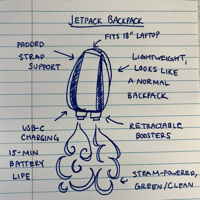

In [ ]:
import requests
import io
from PIL import Image as PILImage
import google.generativeai as genai

# Example Image URL
IMAGE_URL = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png"

# Download and open image
img_bytes = requests.get(IMAGE_URL).content
pil_image = PILImage.open(io.BytesIO(img_bytes))

# Prepare prompt
text_prompt = "Describe the object shown in this image. What might it be used for?"

# Initialize the model (using the MODEL_ID defined earlier)
# Ensure MODEL_ID is defined (from cell 5mr0PtI4NmcV)
try:
    model = genai.GenerativeModel(MODEL_ID)

    # Send multimodal request
    response = model.generate_content(
        contents=[text_prompt, pil_image]
    )

    print(f"Text Prompt: {text_prompt}")
    print(f"Response:\n{response.text}")
except NameError:
    print("Virhe: MODEL_ID ei ole määritelty. Aja solu 1.4 ensin.")

# Display the image
pil_image.resize((200,200))

**Task 3.2: Image Analysis with Gradio**

---

In [ ]:
import gradio as gr
import google.generativeai as genai

def analyze_image_gradio(image_input, text_prompt):
    if image_input is None:
        return "Please upload an image."
    if not text_prompt:
        return "Please enter a text prompt."

    # image_input is already a PIL image due to type="pil"
    pil_image = image_input

    try:
        # Use the GenerativeModel initialized with MODEL_ID
        model = genai.GenerativeModel(MODEL_ID)
        response = model.generate_content(
            contents=[text_prompt, pil_image]
        )
        return response.text
    except NameError:
        return "Virhe: MODEL_ID ei ole määritelty. Aja solu 1.4 ensin."
    except Exception as e:
        return f"Virhe: {str(e)}"

# Create Gradio interface
image_analysis_interface = gr.Interface(
    fn=analyze_image_gradio,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Textbox(lines=2, placeholder="Ask something about the image...", label="Text Prompt")
    ],
    outputs=gr.Markdown(label="Analysis Response"),
    title="Image + Text Analysis with Gemini",
    description="Upload an image and provide a text prompt for Gemini to analyze.",
    flagging_mode='never'
)

image_analysis_interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2280ed18b6c45d31ce.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


##**Part 4: Configuring Generation Parameters**

**Task 4.1: Experiment with Temperature**

---

In [ ]:
# Assumes 'client' was initialized successfully.
creative_prompt = "Write a short poem about a rainy day in Helsinki."
print(f"Prompt: {creative_prompt}\n")

# Low temperature (more focused)
config_low_temp = types.GenerateContentConfig(temperature=0.1)
response_low = client.models.generate_content(
    model=MODEL_ID,
    contents=creative_prompt,
    config=config_low_temp
)
print(f"--- Response (Temperature: 0.1) ---\n{response_low.text}\n")

# High temperature (more creative/random)
config_high_temp = types.GenerateContentConfig(temperature=0.9)
response_high = client.models.generate_content(
    model=MODEL_ID,
    contents=creative_prompt,
    config=config_high_temp
)
print(f"--- Response (Temperature: 0.9) ---\n{response_high.text}\n")


**Task 4.2: Parameter Control with Gradio**

---

In [ ]:
# Assumes 'client' was initialized successfully.
# Ensure the function definition and gr.Interface call are present and executable.
def generate_response_configured(prompt, temperature, max_tokens): # Simplified version
    if not prompt:
        return "Please enter a prompt."

    config = types.GenerateContentConfig(
        temperature=float(temperature),
        max_output_tokens=int(max_tokens)
    )
    # Note: If API call fails here, Gradio might show a generic error.
    response = client.models.generate_content(
        model=MODEL_ID,
        contents=prompt,
        config=config
    )
    return response.text

config_interface = gr.Interface(
    fn=generate_response_configured,
    inputs=[
        gr.Textbox(label="Prompt", lines=3),
        gr.Slider(0.0, 1.0, value=0.5, step=0.1, label="Temperature"),
        gr.Number(value=150, label="Max Output Tokens", precision=0)
    ],
    outputs=gr.Markdown(label="Model Response"),
    title="Gemini Prompt with Config Control",
    description="Experiment with temperature and max tokens."
)
config_interface.launch()

# Note: The full example in the lecture included more parameters (top_k, top_p, etc.)
# You can use that more complete version if preferred.

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d864d59255f62d88ee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


##**Part 5: Multi-turn Chat**

**Task 5.1: Simple Chat Sequence**

---

In [ ]:
# Assumes 'client' was initialized successfully.
# Start chat
chat = client.chats.create(
    model=MODEL_ID,
    config=types.GenerateContentConfig(
        system_instruction="You are a helpful baking assistant."
    )
)
print("Chat session started.\n")

# First message
msg1 = "What are the main steps to bake a simple loaf of bread?"
print(f"User: {msg1}")
response1 = chat.send_message(msg1)
print(f"Assistant:\n{response1.text}\n")

# Second message (contextual)
msg2 = "What kind of flour is generally recommended for the kneading step?"
print(f"User: {msg2}")
response2 = chat.send_message(msg2)
print(f"Assistant:\n{response2.text}\n")
